# Clustering analiza - jesu li klase odvojive?

Cilj: vizualno i kvantitativno provjeriti koliko se 6 klasa (**BIC, CAR, HEAVY, MC, NOISE, TRAM**)
medjusobno razdvaja u prostoru znacajki - prije nego sto krivimo model, provjerimo dopustaju li
same znacajke uopce razdvajanje.

Koristi se isti pipeline znacajki kao u `koji_model_biramo` notebookovima. Postojeci cache s 4
klase se ponovno iskoristava - ekstrakcija se vrti samo za TRAM i NOISE (prvi put), nakon toga
sve ide iz caches.

Redoslijed analize:
1. **PCA** (linearna projekcija) - grubi pregled + koliko varijance objasnjavaju prve komponente
2. **t-SNE** (nelinearna projekcija) - bolje cuva lokalne susjedne odnose, realnija slika odvojivosti
3. **K-Means** (k=6) - da vidimo poklapaju li se "prirodni" clusteri s nasim klasama (Adjusted Rand Index)

In [10]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import signal
from scipy.stats import linregress

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

base_path = '../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC', 'NOISE', 'TRAM']

# Fiksne boje po klasi (uvijek isti redoslijed, nikad ciklicki) + stil grafova
PALETTE = {
    'BIC':   '#2a78d6',  # plava
    'CAR':   '#008300',  # zelena
    'HEAVY': '#e87ba4',  # magenta
    'MC':    '#eda100',  # zuta
    'NOISE': '#1baf7a',  # aqua
    'TRAM':  '#eb6834',  # narancasta
}
SURFACE = '#fcfcfb'
GRID = '#e1e0d9'
MUTED = '#898781'
INK = '#0b0b0b'


def style_ax(ax):
    """Recesivna mreza i osi - podaci u prvom planu, chrome u pozadini."""
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(True, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=8, length=0)

## Pipeline znacajki (identican kao u koji_model_biramo notebookovima)

In [11]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y


LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))
    y_win = y * window
    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2
    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope


def bandwidth_low_band(freqs, psd):
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

## Ucitavanje znacajki (s cacheom)

Cache sa 6 klasa gradi se pametno: postojeci 4-klasni cache (BIC/CAR/HEAVY/MC) se preuzme
gotov, a ekstrakcija se vrti samo za klase koje fale (TRAM, NOISE).

In [12]:
CACHE_6 = '../data/znacajke_cache_6klasa.pkl'
CACHE_4 = '../data/znacajke_cache.pkl'  # stari cache s 4 klase


def extract_class(label):
    folder = os.path.join(base_path, label)
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]
    rows = []
    for i, file in enumerate(files):
        if i % 50 == 0:
            print(f"   {label}: {i}/{len(files)}")
        y, sr = librosa.load(os.path.join(folder, file), sr=None)
        y = y[:sr * 2]  # CLIP_SECONDS = 2
        y = preprocess(y, sr)
        feats = extract_features(y, sr)
        feats['label'] = label
        rows.append(feats)
    return rows


if os.path.exists(CACHE_6):
    df = pd.read_pickle(CACHE_6)
    print(f"Znacajke ucitane iz cachea: {CACHE_6} ({len(df)} uzoraka)")
else:
    parts = []
    have = []
    if os.path.exists(CACHE_4):
        df4 = pd.read_pickle(CACHE_4)
        parts.append(df4)
        have = list(df4['label'].unique())
        print(f"Preuzeto iz starog cachea: {have} ({len(df4)} uzoraka)")

    missing = [c for c in classes if c not in have]
    print(f"Ekstrakcija za: {missing}")
    for label in missing:
        parts.append(pd.DataFrame(extract_class(label)))

    df = pd.concat(parts, ignore_index=True)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]
    df.to_pickle(CACHE_6)
    print(f"Znacajke spremljene u cache: {CACHE_6}")

print("\nBroj uzoraka po klasi:")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

# Standardizacija je nuzna: PCA/t-SNE/K-Means rade na udaljenostima, a znacajke su na
# potpuno razlicitim skalama (rms ~0.01 vs spectral_centroid ~1000).
X_scaled = StandardScaler().fit_transform(X)

Znacajke ucitane iz cachea: ../data/znacajke_cache_6klasa.pkl (13668 uzoraka)

Broj uzoraka po klasi:
label
CAR      9348
NOISE    1577
HEAVY    1190
TRAM      700
MC        519
BIC       334
Name: count, dtype: int64


## 1. PCA - linearna projekcija u 2D

PCA cuva globalnu strukturu i pokazuje koliko su klase odvojive *linearnim* kombinacijama
znacajki. Ako se klase ovdje preklapaju, to jos ne znaci da su neodvojive - zato poslije
gledamo i t-SNE.

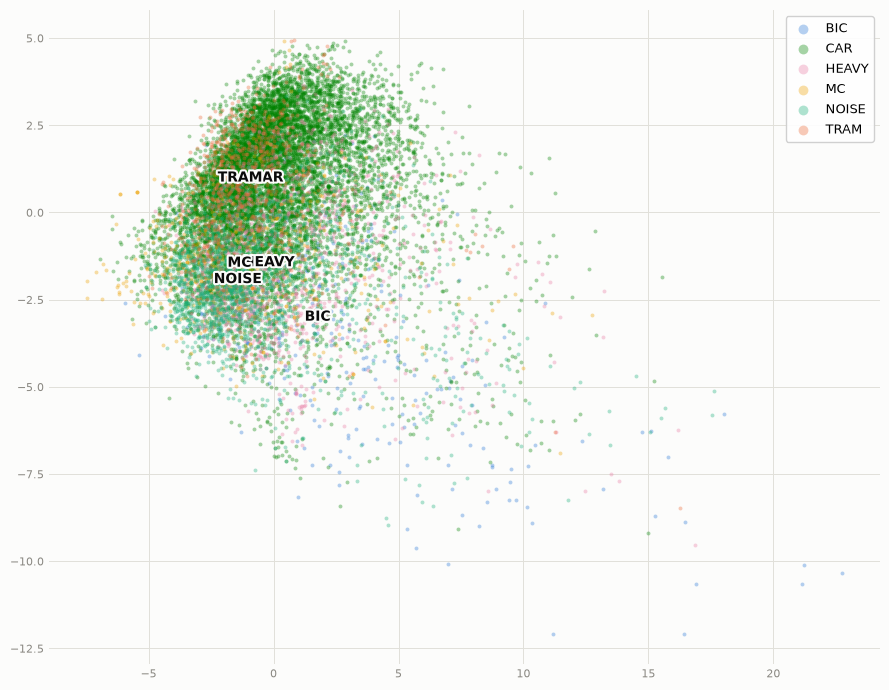

Prve 2 komponente objasnjavaju 49% varijance


In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7), facecolor=SURFACE)
for cls in classes:
    m = (y == cls).to_numpy()
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.35, linewidths=0,
               color=PALETTE[cls], label=cls)

# Direktne oznake na medijanu svake klase - identitet ne smije nositi samo boja
for cls in classes:
    m = (y == cls).to_numpy()
    cx, cy = np.median(X_pca[m, 0]), np.median(X_pca[m, 1])
    ax.annotate(cls, (cx, cy), fontsize=10, fontweight='bold', color=INK,
                ha='center', path_effects=[pe.withStroke(linewidth=3, foreground=SURFACE)])

style_ax(ax)
# ax.set_xlabel(f'PC1 ({var[0]:.0%} varijance)', color=MUTED)
#ax.set_ylabel(f'PC2 ({var[1]:.0%} varijance)', color=MUTED)
#ax.set_title('PCA projekcija svih 6 klasa', color=INK, fontsize=12)
leg = ax.legend(markerscale=2.5, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Prve 2 komponente objasnjavaju {var.sum():.0%} varijance")

### PCA po klasama (facet pogled)

Sa 6 klasa na jednom scatteru boje se tesko razlikuju u preklapajucim zonama - zato svaku
klasu gledamo u svom panelu, obojanu naspram svih ostalih u sivom. Ovo je najcitljiviji
pogled na odvojivost: odmah se vidi "zivi" li klasa u svom podrucju ili je razmazana
preko svega.

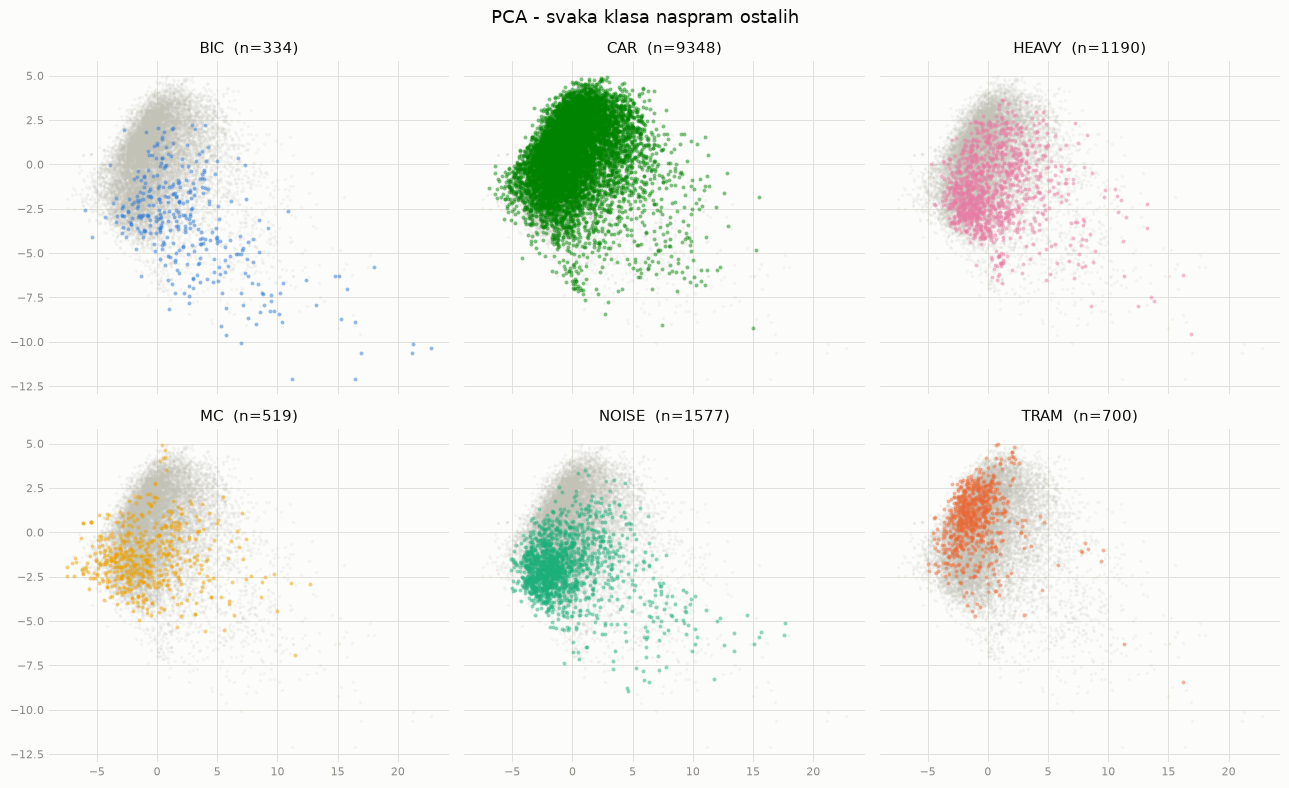

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), facecolor=SURFACE,
                         sharex=True, sharey=True)
for ax, cls in zip(axes.ravel(), classes):
    m = (y == cls).to_numpy()
    ax.scatter(X_pca[~m, 0], X_pca[~m, 1], s=5, alpha=0.15, linewidths=0, color='#c3c2b7')
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.5, linewidths=0, color=PALETTE[cls])
    style_ax(ax)
    ax.set_title(f'{cls}  (n={m.sum()})', color=INK, fontsize=11)

fig.suptitle('PCA - svaka klasa naspram ostalih', color=INK, fontsize=13)
plt.tight_layout()
plt.show()

## 2. t-SNE - nelinearna projekcija

t-SNE cuva lokalne susjedne odnose pa puno bolje otkriva stvarne grupe nego PCA. Radi na
balansiranom poduzorku (max 400 po klasi) - inace CAR s ~9000 uzoraka vizualno preplavi
sve ostale, a i t-SNE je spor na 13k+ tocaka.

In [15]:
rng = np.random.default_rng(42)
idx_parts = []
for cls in classes:
    idx_cls = np.flatnonzero((y == cls).to_numpy())
    take = min(400, len(idx_cls))
    idx_parts.append(rng.choice(idx_cls, size=take, replace=False))
idx_sub = np.concatenate(idx_parts)

X_sub = X_scaled[idx_sub]
y_sub = y.to_numpy()[idx_sub]
print(f"Poduzorak za t-SNE: {len(idx_sub)} tocaka")

tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_sub)

Poduzorak za t-SNE: 2334 tocaka


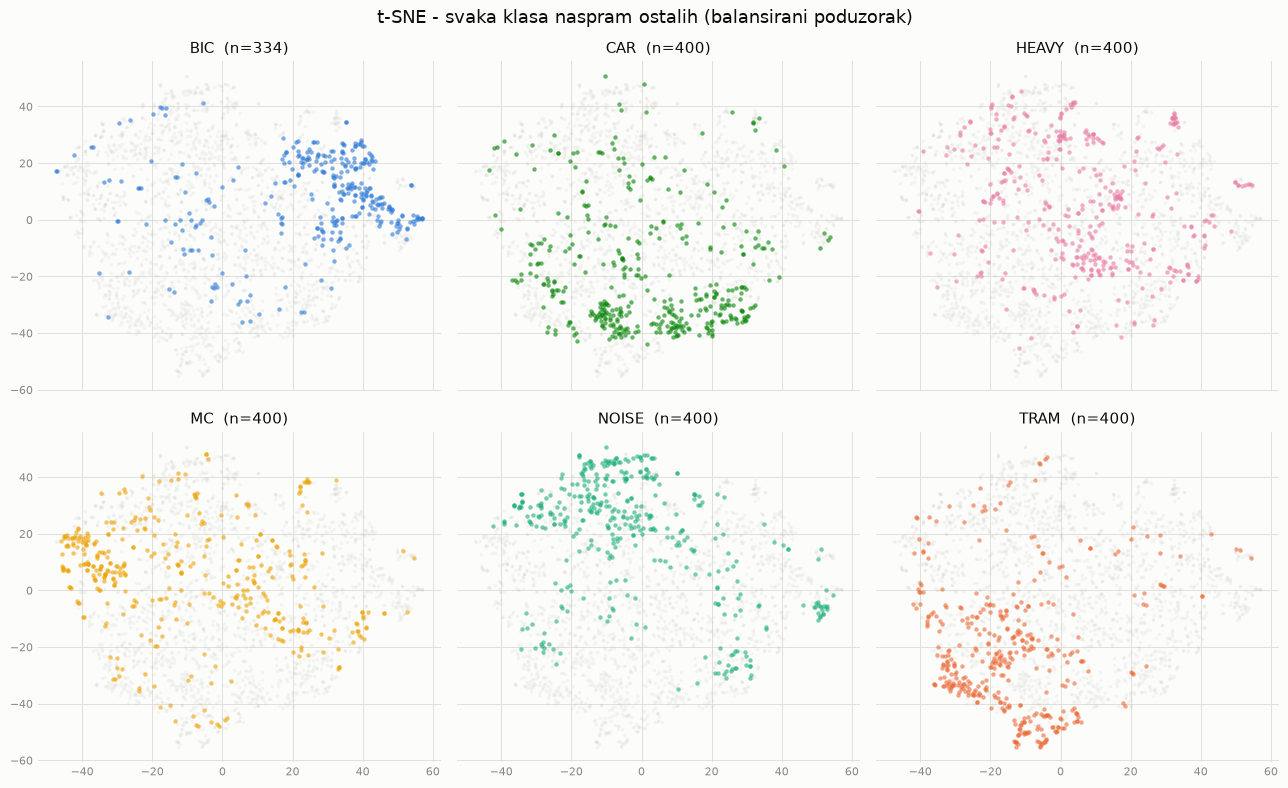

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), facecolor=SURFACE,
                         sharex=True, sharey=True)
for ax, cls in zip(axes.ravel(), classes):
    m = y_sub == cls
    ax.scatter(X_tsne[~m, 0], X_tsne[~m, 1], s=6, alpha=0.15, linewidths=0, color='#c3c2b7')
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], s=10, alpha=0.6, linewidths=0, color=PALETTE[cls])
    style_ax(ax)
    ax.set_title(f'{cls}  (n={m.sum()})', color=INK, fontsize=11)

fig.suptitle('t-SNE - svaka klasa naspram ostalih (balansirani poduzorak)',
             color=INK, fontsize=13)
plt.tight_layout()
plt.show()

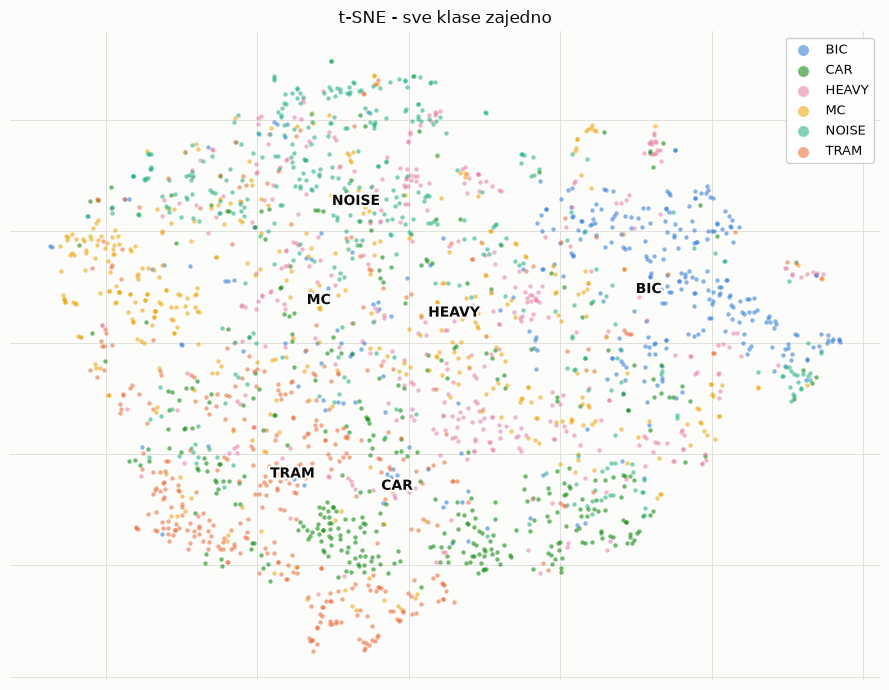

In [17]:
fig, ax = plt.subplots(figsize=(9, 7), facecolor=SURFACE)
for cls in classes:
    m = y_sub == cls
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], s=10, alpha=0.55, linewidths=0,
               color=PALETTE[cls], label=cls)

for cls in classes:
    m = y_sub == cls
    cx, cy = np.median(X_tsne[m, 0]), np.median(X_tsne[m, 1])
    ax.annotate(cls, (cx, cy), fontsize=10, fontweight='bold', color=INK,
                ha='center', path_effects=[pe.withStroke(linewidth=3, foreground=SURFACE)])

style_ax(ax)
ax.set_title('t-SNE - sve klase zajedno', color=INK, fontsize=12)
ax.set_xticklabels([]); ax.set_yticklabels([])  # t-SNE osi nemaju fizikalno znacenje
ax.legend(markerscale=2.5, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

## 3. K-Means - poklapaju li se "prirodni" clusteri s klasama?

Pustimo K-Means (k=6, bez labela!) i usporedimo dobivene clustere s pravim klasama:

- **Adjusted Rand Index (ARI)**: 1.0 = clusteri savrseno odgovaraju klasama, ~0 = slucajno
- **Heatmapa cluster x klasa**: svaki stupac (klasa) normaliziran na 100% - vidi se u koje
  se clustere svaka klasa raspada. Klasa koja "zivi" u jednom clusteru je kompaktna;
  klasa razmazana preko vise clustera akusticki nije homogena.

Adjusted Rand Index (cluster vs klasa): 0.085
Silhouette score clusteringa:           0.124


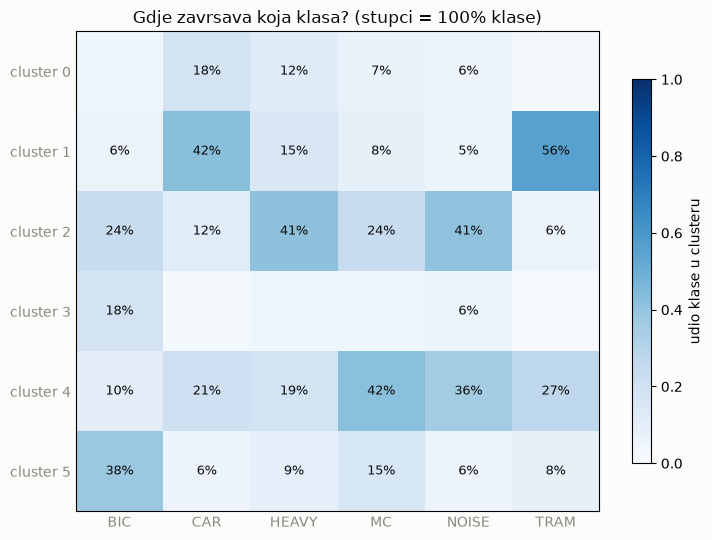

In [19]:
km = KMeans(n_clusters=len(classes), n_init=10, random_state=42)
cluster_ids = km.fit_predict(X_scaled)

ari = adjusted_rand_score(y, cluster_ids)
sil = silhouette_score(X_scaled, cluster_ids, sample_size=3000, random_state=42)
print(f"Adjusted Rand Index (cluster vs klasa): {ari:.3f}")
print(f"Silhouette score clusteringa:           {sil:.3f}")

ct = pd.crosstab(cluster_ids, y)
ct = ct[classes]
ct_pct = ct / ct.sum(axis=0)  # normalizacija po klasi (stupcu)

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=SURFACE)
im = ax.imshow(ct_pct, cmap='Blues', vmin=0, vmax=1, aspect='auto')

for i in range(ct_pct.shape[0]):
    for j in range(ct_pct.shape[1]):
        v = ct_pct.iloc[i, j]
        if v >= 0.05:  # oznacavamo samo znacajne celije, ne svaku
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9,
                    color='white' if v > 0.6 else INK)

ax.set_xticks(range(len(classes)), classes)
ax.set_yticks(range(ct_pct.shape[0]), [f'cluster {c}' for c in ct_pct.index])
ax.tick_params(colors=MUTED, length=0)
ax.set_title('Gdje zavrsava koja klasa? (stupci = 100% klase)', color=INK, fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.8, label='udio klase u clusteru')
plt.tight_layout()
plt.show()

## Kako citati rezultate

- **Klasa je dobro odvojiva** ako u facet pogledima (PCA/t-SNE) zauzima svoje kompaktno
  podrucje, i ako u K-Means heatmapi vecina njenog stupca sjedi u jednom clusteru.
- **Preklapanje na PCA, ali odvojenost na t-SNE** znaci da razdvajanje postoji, ali je
  nelinearno - tree modeli (RF/XGBoost) to mogu iskoristiti, linearni modeli ne.
- **Preklapanje i na t-SNE** (tipicno ocekivano za MC vs CAR, ili NOISE razmazan posvuda)
  znaci da s ovim znacajkama te klase dijele akusticki prostor - nijedan model ih nece
  cisto razdvojiti bez novih znacajki ili vise podataka.
- ARI blizu 0 uz vizualno jasne grupe znaci da prirodno grupiranje postoji, ali ne prati
  nase klase (npr. grupira po glasnoci snimke, a ne po tipu vozila).